# Nearly-Periodic Coupled Oscillators: ML Model Evaluation

## Overview

This notebook evaluates neural network (NN) flow maps for the nearly-periodic coupled oscillators (NPCO) problem.

In particular, this notebook will:
1. Load trained NN flow maps from specified checkpoint files.
2. Benchmark the NN forward pass runtime.
3. Generate and compare trajectories using the NN flow maps versus reference solutions, supporting both one-step and recursive prediction modes.

## Mathematical Model

The system is described by the Hamiltonian:

$$ H_\varepsilon (q_1,q_2,p_1,p_2) = \frac{1}{2} (q_1^2 + p_1^2 ) + \frac{1}{2} \varepsilon (q_2^2 + p_2^2 )  + \varepsilon U(q_1,q_2) $$

where the coupling potential is:
$$ U(q_1,q_2) = q_1 q_2 \sin(2q_1 + 2q_2) $$

The equations of motion are:
$$ \begin{cases} \dot{q}_1 = p_1 \qquad & \dot{p}_1 = -q_1 - \varepsilon \partial_{q_1} U(q_1,q_2) \\ \dot{q}_2 = \varepsilon p_2 \qquad & \dot{p}_2 = -\varepsilon q_2 - \varepsilon \partial_{q_2} U(q_1,q_2)
\end{cases} $$

This system exhibits interesting dynamics with coupling parameter $\varepsilon$ controlling the strength of interaction between the oscillators.


## Setup and Dependencies

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import time
import torch

from notebook_utils.dataprocessing import NCO, NCOTrajectory, NCODataset
from notebook_utils.visualization import NCOVisualizer
from notebook_utils.evaluation import (
    find_latest_ckpt, load_model_from_ckpt, time_forward,
    one_step_predict, recursive_predict, 
)

Trajectory = NCOTrajectory
Dataset = NCODataset
viz = NCOVisualizer()

## Load Models


In [2]:
ALL_MODELS = {
    ### Taylor IdEnf models 
    "Taylor0IdEnf: VV uniform(0,5) h=0.01": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250324-033756_2i8rgg/checkpoints",
    },
    "Taylor1IdEnf: VV uniform(0,5) h=0.01": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250324-030932_rpkcaw/checkpoints",
    },
    "Taylor2IdEnf: VV uniform(0,5) h=0.01": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250323-234359_zk28ds/checkpoints",
    },
    "Taylor2IdEnf: IM uniform(0,5) h=0.01": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250324-004229_vvfuet/checkpoints",
    },
    "Taylor2IdEnf: VV uniform(0,5) h=0.01, EBE": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250325-024825_wceux9/checkpoints",
    },
    "Taylor2IdEnf: VV uniform(0,5) h=0.01 trained for 5M steps": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250325-111045_2zcxko/checkpoints",
    },
    "Taylor2IdEnf: VV uniform(0,10) h=0.01": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250325-165015_78pn8k/checkpoints",
    },
    "Taylor0IdEnf: VV uniform(0,15) h=0.01": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250326-220252_1ku441/checkpoints",
    },
    "Taylor2IdEnf: VV uniform(0,15) h=0.01": {
        "model_name": "TaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250326-220228_srof1s/checkpoints",
    },
    ### SF Taylor models (nondim incorporates permutation, different from nondim used for Taylor models)
    "S0F0TaylorIdEnf: VV uniform(0,20) h=0.01": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250327-160350_h3zoi9/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,20) h=0.01": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250327-155830_ymekwn/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,30) h=0.01": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250329-142604_mngtlq/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,40) h=0.01": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250330-122239_3a7xcd/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,80) h=0.01": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250331-232552_6x8t3p/checkpoints",
    },
    "S2F0TaylorIdEnf: VV uniform(0,40) h=0.01, trained for 5M steps": {
        "model_name": "SFTaylorBasedIdentityEnforcedSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250401-214303_h6s8w7/checkpoints",
    },
    ### HMC data (version 22)
    "T0Centered: data at 5, MSE": {
        "model_name": "TaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250324-183507_j39va5/checkpoints",
    },
    "T0Centered: data at 10, EBE": {
        "model_name": "T0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250322-153443_elksku/checkpoints",
    },
    "T0Centered: data at 10 + IM normal(10,1) h=0.01, EBE": {
        "model_name": "TaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20250322-174816_sizrf3/checkpoints",
    },
    ### HMC data (202510071037_rhmc-H0)
    "T0Centered: data at 5": {
        "model_name": "TaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20251008-213433_f353if/checkpoints",
    },
    "T0Centered: data at 5 + VV normal(5,0.5) h=0.01": {
        "model_name": "TaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20251009-163828_hsvgy1/checkpoints",
    },
    "T0Centered: data at 5 + IM normal(5,0.5) h=0.01": {
        "model_name": "TaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20251009-163718_phx29b/checkpoints",
    },
    "T0Centered: data at 5 v2": {
        "model_name": "TaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20251011-045226_f0w36i/checkpoints",
    },
    "T0Centered: data at 5 + VV normal(5,0.5) h=0.01 v2": {
        "model_name": "TaylorBasedT0CenteredSolutionMap",
        "ckpt_dir": "../../deep_learning/logs/train/runs/20251011-044500_hrb61t/checkpoints",
    },
}

In [3]:
# Select models to evaluate
# SELECTED_MODELS = [
#     "S2F0TaylorIdEnf: VV uniform(0,20) h=0.01",
#     "S2F0TaylorIdEnf: VV uniform(0,40) h=0.01",
#     "S2F0TaylorIdEnf: VV uniform(0,80) h=0.01",
# ]  # Experiment with the learnable time interval

# SELECTED_MODELS = [
#     "Taylor2IdEnf: VV uniform(0,5) h=0.01 trained for 5M steps",
# ]  # Best model for this problem

SELECTED_MODELS = [
    "T0Centered: data at 5",
    # "T0Centered: data at 5 v2",
    "T0Centered: data at 5 + VV normal(5,0.5) h=0.01",
    "T0Centered: data at 5 + IM normal(5,0.5) h=0.01",
]  # Experiment with residual regularization 

models = []
model_labels = []
for key in SELECTED_MODELS:
    ckpt_info = ALL_MODELS[key]
    ckpt_path = find_latest_ckpt(ckpt_info["ckpt_dir"])
    model, _ = load_model_from_ckpt(ckpt_path, ckpt_info["model_name"], load_net_T0_only=True)
    print(f"Model loaded from checkpoint {ckpt_path}")
    print(model)
    model.to(torch.float64)
    print(f"Model dtype: {model.dtype}")
    models.append(model)
    model_labels.append(key)


5 4
<All keys matched successfully>
Model loaded from checkpoint ../../deep_learning/logs/train/runs/20251008-213433_f353if/checkpoints/latest-epoch05208.ckpt
TaylorBasedT0CenteredSolutionMap(
  problem: NCO(epsilon=0.01)
  use_dimensionless: True
  problem_param_keys: []
  T0: 5.0
  order: 0
  (loss_fn): MSELoss()
  (net): PirateNet(
    (encoder1): Linear(in_features=5, out_features=1000, bias=True)
    (encoder2): Linear(in_features=5, out_features=1000, bias=True)
    (input_layer): Linear(in_features=5, out_features=1000, bias=True)
    (output_layer): Linear(in_features=1000, out_features=4, bias=False)
    (res_blocks): ModuleList(
      (0-1): 2 x PirateNetBlock(
        (linears): ModuleList(
          (0-2): 3 x Linear(in_features=1000, out_features=1000, bias=True)
        )
        (activation): ELU(alpha=1.0)
      )
    )
    (activation): ELU(alpha=1.0)
  )
  (mult_act): Tanh()
  (net_T0): PirateNet(
    (encoder1): Linear(in_features=4, out_features=1000, bias=True)
   

## Analysis


### 1. Runtime

Measure forward pass runtime


In [4]:
for model, label in zip(models, model_labels):
    compare = time_forward(model, nsteps_list=[0, 1])
    print(f"Model: {label}")
    print(compare)

Model: T0Centered: data at 5
[-------------------------------------- forward time --------------------------------------]
                                                          |  cpu: nsteps=0  |  cpu: nsteps=1
1 threads: ---------------------------------------------------------------------------------
      u: torch.Size([1, 4]), t: torch.Size([1, 1])        |      174.4      |     4789417.0 
      u: torch.Size([64, 4]), t: torch.Size([64, 1])      |      174.2      |    17502291.5 
      u: torch.Size([128, 4]), t: torch.Size([128, 1])    |      173.3      |    31696000.0 
      u: torch.Size([512, 4]), t: torch.Size([512, 1])    |      171.5      |   110559667.0 
      u: torch.Size([1024, 4]), t: torch.Size([1024, 1])  |      173.4      |   221987041.1 
      u: torch.Size([2048, 4]), t: torch.Size([2048, 1])  |      173.0      |   451403875.0 

Times are in nanoseconds (ns).

Model: T0Centered: data at 5 + VV normal(5,0.5) h=0.01
[-------------------------------------- forwar

### 2. 1-Step Predictions

Evaluate the model at different times


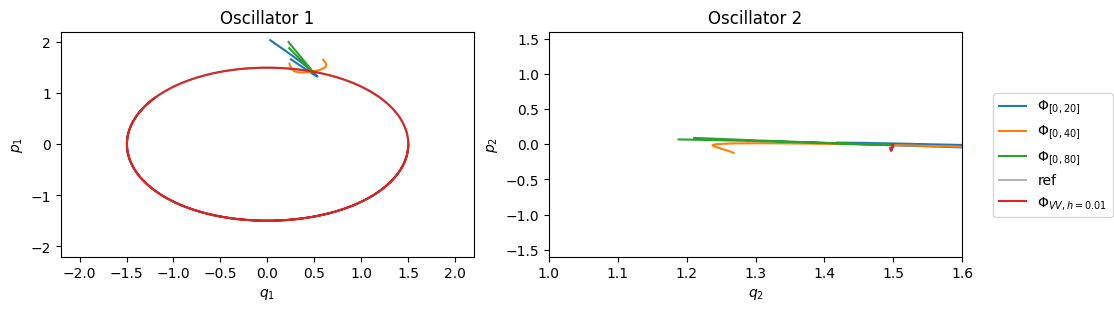

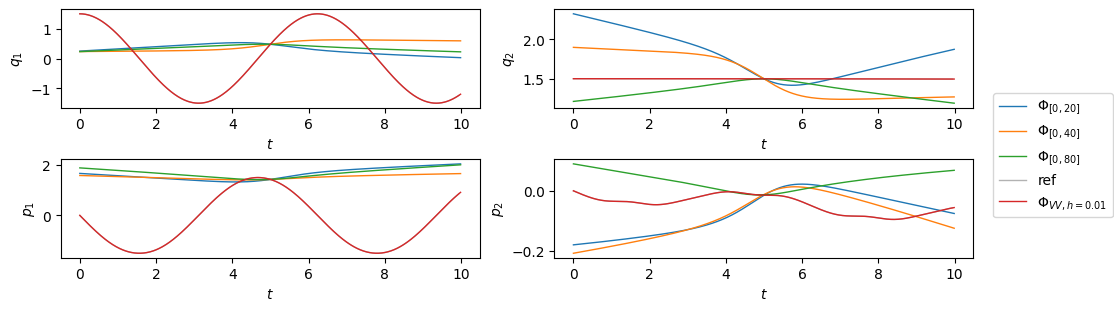

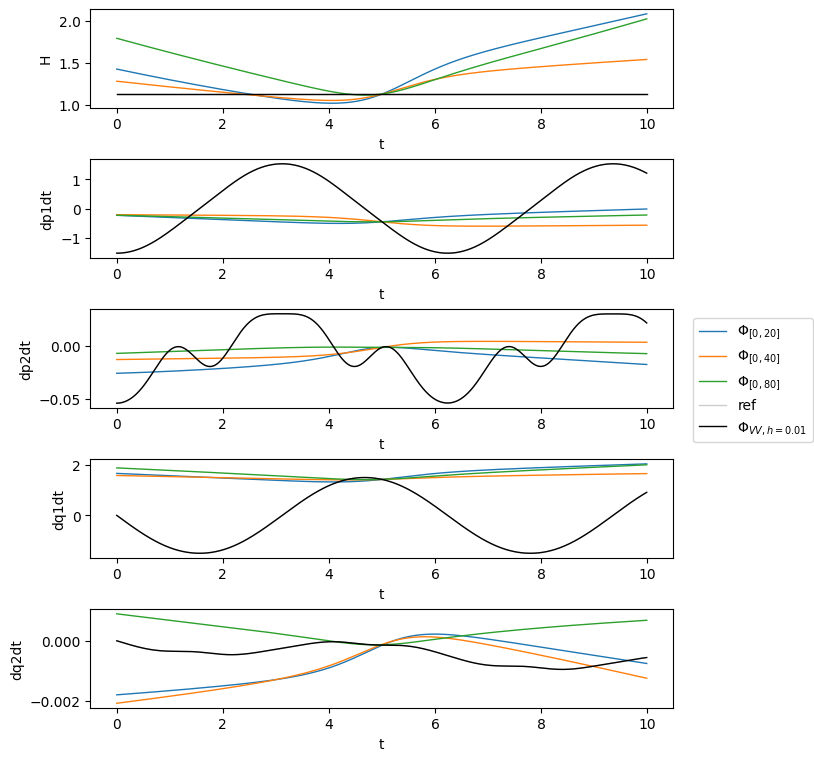

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 9.950000000000001], dt=0.05, u0=[ 1.65861802e+00 -1.78900384e-03  2.50397444e-01  2.32643282e+00], states=States(problem=NCO(epsilon=0.01), shape=(200, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 9.950000000000001], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(200, 4)))
$\Phi_{[0,20]}$ n=1 osc1_rel_traj_err = 1.4210641471293404
$\Phi_{[0,20]}$ n=199 osc1_rel_traj_err = 1.1462567749108956
$\Phi_{[0,20]}$ n=1 osc2_rel_traj_err = 0.5594520406864727
$\Phi_{[0,20]}$ n=199 osc2_rel_traj_err = 0.2503132508698065
$\Phi_{[0,20]}$ n=1 rel_traj_err = 1.0799223809463112
$\Phi_{[0,20]}$ n=199 rel_traj_err = 0.8309963063372244
$\Phi_{[0,20]}$ n=1 abs_H_err = 0.29217669799956125
$\Phi_{[0,20]}$ n=199 abs_H_err = 0.953455315119766
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 9.950000000000001], dt=0.05, u0=[ 1.57610858 -0.00206761  0.23429882  1.89920038], states=States(problem=NCO(epsilon=0.01), shape=(2

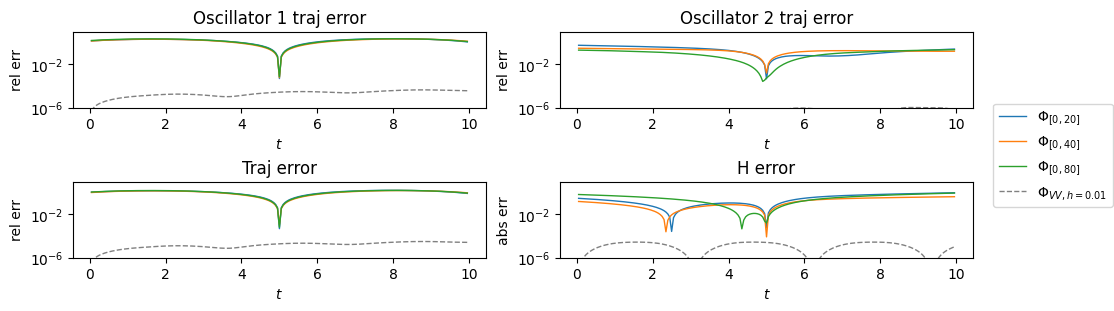

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 9.99], dt=0.01, u0=[ 1.65861802e+00 -1.78900384e-03  2.50397444e-01  2.32643282e+00], states=States(problem=NCO(epsilon=0.01), shape=(1000, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 9.99], dt=0.01, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(1000, 4)))
T0Centered: data at 5 n=1 osc1_rel_traj_err = 1.391841633929163
T0Centered: data at 5 n=999 osc1_rel_traj_err = 1.1064092013798201
T0Centered: data at 5 n=1 osc2_rel_traj_err = 0.5628634778830773
T0Centered: data at 5 n=999 osc2_rel_traj_err = 0.2533657347983064
T0Centered: data at 5 n=1 rel_traj_err = 1.0616121025451262
T0Centered: data at 5 n=999 rel_traj_err = 0.8040527399910974
T0Centered: data at 5 n=1 abs_H_err = 0.2975110014459992
T0Centered: data at 5 n=999 abs_H_err = 0.9592055052269688
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 9.99], dt=0.01, u0=[ 1.57610858 -0.00206761  0.23429882  1.89920038], states=States(problem=NCO(epsilon=0.01)

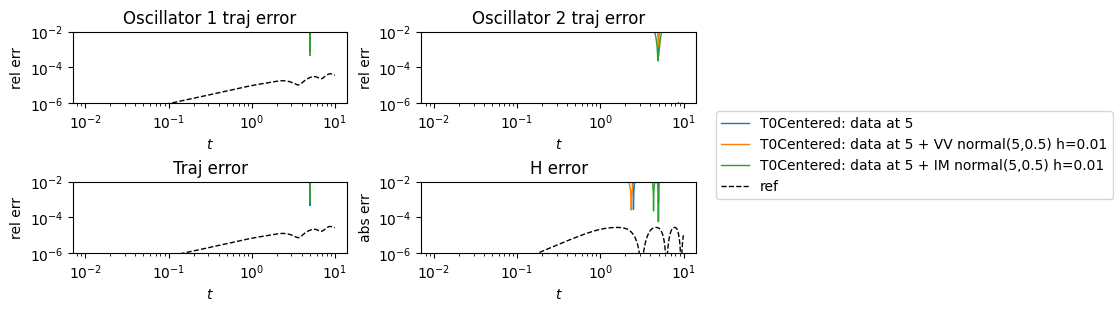

In [5]:
def trajectory_from_taylor_expansion(u0, times, p, order):
    """Generate trajectory using Taylor series expansion."""
    processor = NCO(**p)
    u = processor.compute_taylor_series(u0, times, order)
    return Trajectory.from_vx(times, u, **p)

def build_trajectory_list(pred_trajs, model_labels, ref_traj, coarse_ref_traj, taylor_trajs, 
                         show_coarse_ref, show_taylor, t_list):
    """Build lists of trajectories, labels, and colors for plotting."""
    trajs = pred_trajs.copy()
    labels = model_labels.copy()
    colors = [f"C{i}" for i in range(len(model_labels))]
    
    # Add reference
    if ref_traj:
        trajs.append(ref_traj.select_between(t_list.min(), t_list.max()))
        labels.append("ref")
        colors.append("black")
    
    # Add coarse reference if requested
    if show_coarse_ref and coarse_ref_traj:
        trajs.append(coarse_ref_traj.select_between(t_list.min(), t_list.max()))
        labels.append(r"$\Phi_{VV, h=0.01}$")
        colors.append("grey")
    
    # Add Taylor trajectories if requested
    if show_taylor:
        trajs.extend(taylor_trajs)
        labels.extend([f"Taylor order {i+1}" for i in range(len(taylor_trajs))])
        colors.extend(["red", "green"][:len(taylor_trajs)])
    
    return trajs, labels, colors

# Configuration
epsilon = 0.01
params = {"epsilon": epsilon}
processor = NCO(epsilon=epsilon)
ref_traj_idx = 1

# Display options
show_coarse_ref = True
show_taylor = False
taylor_orders = [1, 2]

# Load trajectories
ref_filepaths = NCO.get_reference_filepaths('constant_energy')
ref_traj = Trajectory.load_from_file(
    ref_filepaths[epsilon][ref_traj_idx]["filepath"], 
    dt=ref_filepaths[epsilon][ref_traj_idx]["dt"], **params
)
u0 = ref_traj.states.u[0]

coarse_ref_traj = None
if show_coarse_ref:
    coarse_ref_filepaths = NCO.get_reference_filepaths('vv_constant_energy')
    coarse_ref_traj = Trajectory.load_from_file(
        coarse_ref_filepaths[epsilon][ref_traj_idx]["filepath"], 
        dt=coarse_ref_filepaths[epsilon][ref_traj_idx]["dt"], **params
    )

# Generate predictions
t_list = np.arange(0, 10, 0.01)
pred_trajs = [Trajectory.from_vx(t_list, one_step_predict(model, u0, t_list, params), **params) 
              for model in models]

taylor_trajs = []
if show_taylor:
    taylor_trajs = [trajectory_from_taylor_expansion(u0, t_list, params, order) 
                    for order in taylor_orders]

# --- Plot ---

# Set model labels for plotting
model_labels_for_plotting = [
    r"$\Phi_{[0,20]}$", 
    r"$\Phi_{[0,40]}$", 
    r"$\Phi_{[0,80]}$"
]
# If you want to use the original model_labels, uncomment the following line:
# model_labels_for_plotting = model_labels

# Gather all trajectories, their corresponding labels, and colors for visualization
all_trajs, all_labels, all_colors = build_trajectory_list(
    pred_trajs, model_labels_for_plotting, ref_traj, coarse_ref_traj, taylor_trajs, 
    show_coarse_ref, show_taylor, t_list
)

# Set axis limits for phase space plots
# Format: [[(q1_min, q1_max), (p1_min, p1_max)], [(q2_min, q2_max), (p2_min, p2_max)]]
phase_space_axis_lims = [
    [(-2.2, 2.2), (-2.2, 2.2)],   # Oscillator 1: (q1, p1)
    [(1.0, 1.6), (-1.6, 1.6)]     # Oscillator 2: (q2, p2)
]
q1_lim, p1_lim = phase_space_axis_lims[0]
q2_lim, p2_lim = phase_space_axis_lims[1]


# Plot phase space trajectories for both oscillators
viz.plot_phase_space(
    all_trajs,
    axis_lims=phase_space_axis_lims,
    legend_labels=all_labels, 
    show_legend=True,
    figsize=(11, 3)
)

# Plot (q, p) vs time for both oscillators
viz.plot_pq_vs_t(
    all_trajs,
    y_lims=[q1_lim, q2_lim, p1_lim, p2_lim],
    legend_labels=all_labels, 
    show_legend=True,
    figsize=(11, 3)
)

# Plot time histories for key physical quantities
viz.plot_history(
    all_trajs,
    func_dict={
        'H': lambda u: processor.compute_hamiltonian(u),
        'dp1dt': lambda u: processor.compute_du(u)[:, 0],
        'dp2dt': lambda u: processor.compute_du(u)[:, 1],
        'dq1dt': lambda u: processor.compute_du(u)[:, 2],
        'dq2dt': lambda u: processor.compute_du(u)[:, 3],
    },
    xlabel='t',
    legend_labels=all_labels,
    colors=all_colors,
    show_legend=True,
)

# Plot errors against reference
error_trajs, error_labels, error_colors = build_trajectory_list(
    pred_trajs, model_labels_for_plotting, None, coarse_ref_traj, taylor_trajs, 
    show_coarse_ref, show_taylor, t_list
)
error_linestyles = ["-"] * len(model_labels) + (["--"] if show_coarse_ref else []) + (["-."] * len(taylor_trajs) if show_taylor else [])

viz.plot_errors(
    error_trajs, ref_traj, legend_labels=error_labels, 
    error_names=["osc1_rel_traj_err", "osc2_rel_traj_err", "rel_traj_err", "abs_H_err"], 
    show_legend=True, linestyles=error_linestyles, colors=error_colors,
    ylims=[(1e-6, 1e1)]*4, log_xscale=False, figsize=(11, 3),
)

# Plot errors against coarse reference if available
if show_coarse_ref and coarse_ref_traj:
    coarse_error_trajs, coarse_error_labels, coarse_error_colors = build_trajectory_list(
        pred_trajs, model_labels, ref_traj, None, taylor_trajs, False, show_taylor, t_list
    )
    coarse_error_linestyles = ["-"] * len(model_labels) + ["--"] + (["-."] * len(taylor_trajs) if show_taylor else [])
    
    viz.plot_errors(
        coarse_error_trajs, coarse_ref_traj, 
        error_names=["osc1_rel_traj_err", "osc2_rel_traj_err", "rel_traj_err", "abs_H_err"], 
        legend_labels=coarse_error_labels, show_legend=True, 
        linestyles=coarse_error_linestyles, colors=coarse_error_colors,
        ylims=[(1e-6, 1e-2)]*4, log_xscale=True, figsize=(11, 3), 
    )


In [5]:
# error_colors = ["C0", "C2", "C3", "k"]
viz.plot_errors_matlab(
    error_trajs, ref_traj, legend_labels=error_labels, 
    show_legend=True, linestyles=error_linestyles, colors=error_colors,
    ylims=[(1e-6, 1e1)]*4, log_xscale=False, figsize=(11, 6),
    save_path=f"./out/nco/eps=1e-2/various_T/errors_matlab.pdf",
)

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 79.95], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(1600, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 79.95], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(1600, 4)))
$\Phi_{[0,20]}$ n=1 osc1_abs_traj_err = 8.381885421257522e-05
$\Phi_{[0,20]}$ n=1599 osc1_abs_traj_err = 145.8525436074626
$\Phi_{[0,20]}$ n=1 osc2_abs_traj_err = 1.0537744771970197e-06
$\Phi_{[0,20]}$ n=1599 osc2_abs_traj_err = 50.55637522272158
$\Phi_{[0,20]}$ n=1 abs_traj_err = 8.382547800136739e-05
$\Phi_{[0,20]}$ n=1599 abs_traj_err = 154.36616064548406
$\Phi_{[0,20]}$ n=1 abs_H_err = 1.8733943305537792e-06
$\Phi_{[0,20]}$ n=1599 abs_H_err = 10778.322872248058
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 79.95], dt=0.05, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(1600, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 79.95], dt=0.05, u0=[0.  0.  1.5 1.5], states=St

### 3. Recursive Predictions

Repeatedly applying the model with a fixed time step (dt)


Model: T0Centered: data at 5
	dt=5.0 Recursive prediction time: 2.15e+00s
Model: T0Centered: data at 5 + VV normal(5,0.5) h=0.01
	dt=5.0 Recursive prediction time: 2.13e+00s
Model: T0Centered: data at 5 + IM normal(5,0.5) h=0.01
	dt=5.0 Recursive prediction time: 1.94e+00s


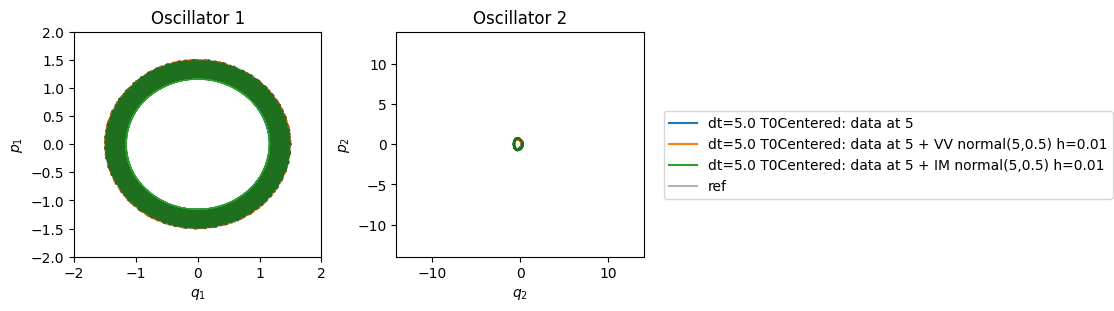

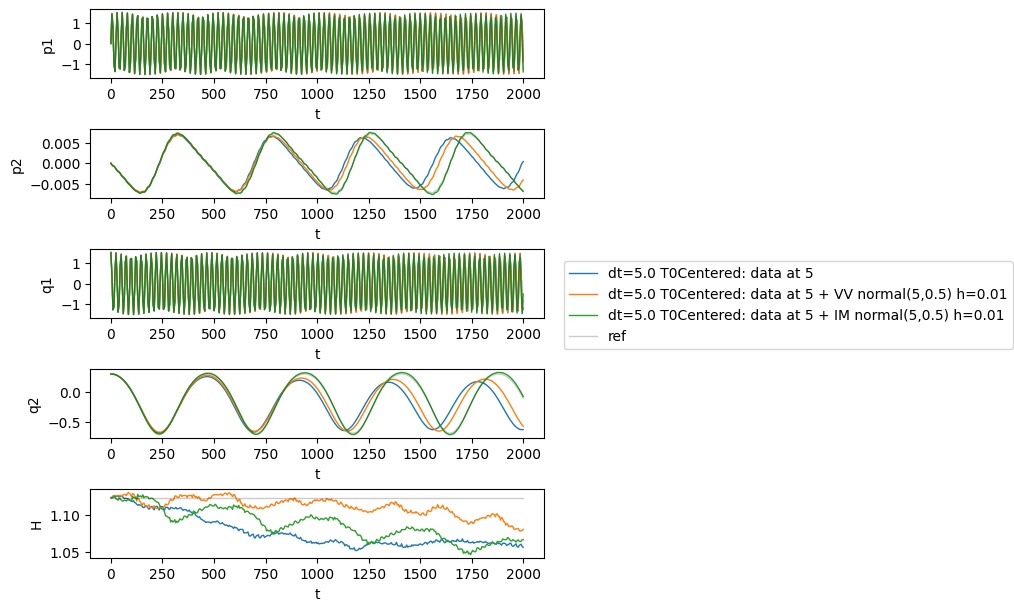

After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 0.3], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
	ref_traj = NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 0.3], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
dt=5.0 T0Centered: data at 5 n=1 osc1_rel_traj_err = 0.00015795415124863476
dt=5.0 T0Centered: data at 5 n=400 osc1_rel_traj_err = 0.44781629193194544
dt=5.0 T0Centered: data at 5 n=1 osc2_rel_traj_err = 0.0028202491875174
dt=5.0 T0Centered: data at 5 n=400 osc2_rel_traj_err = 1.3063949933938737
dt=5.0 T0Centered: data at 5 n=1 rel_traj_err = 0.0005779597248241607
dt=5.0 T0Centered: data at 5 n=400 rel_traj_err = 0.6734862130451186
dt=5.0 T0Centered: data at 5 n=1 abs_H_err = 3.492288727957593e-05
dt=5.0 T0Centered: data at 5 n=400 abs_H_err = 0.06689469337148912
After alignment: 
	traj = NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 0.3], states=States(problem=NCO(epsilon=0.01), shape=(4

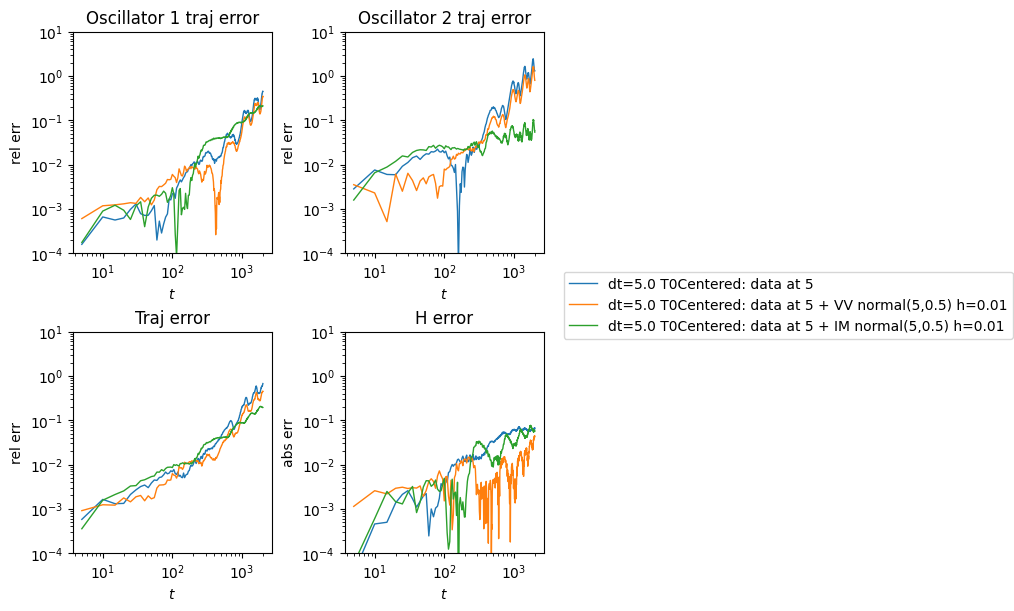

In [6]:
def build_recursive_trajectory_list(pred_trajs, labels, ref_traj, dt_list, T_end):
    """Build lists of trajectories, labels, and colors for recursive prediction plotting."""
    all_trajs = pred_trajs.copy()
    all_labels = labels.copy()
    all_colors = [f"C{i}" for i in range(len(pred_trajs))]
    
    # Add reference trajectory
    ref_traj_selected = ref_traj.select_with_interval(min(dt_list)).select_between(0, T_end)
    all_trajs.append(ref_traj_selected)
    all_labels.append("ref")
    all_colors.append("black")
    
    return all_trajs, all_labels, all_colors

# Configuration
epsilon = 0.01
params = {"epsilon": epsilon}
processor = NCO(epsilon=epsilon)
ref_traj_idx = 3

# Recursive prediction parameters
T_end = 2000
dt_list = [5.0]  # Time steps for recursive evaluation
show_timing = True  # Whether to show prediction timing

# Load reference trajectory
ref_filepaths = NCO.get_reference_filepaths('fixed_q1')
ref_traj = Trajectory.load_from_file(
    ref_filepaths[epsilon][ref_traj_idx]["filepath"], 
    dt=ref_filepaths[epsilon][ref_traj_idx]["dt"], **params
)
u0 = ref_traj.states.u[0]

# Generate recursive predictions: φ(φ(φ(u₀,dt),dt),dt)...
pred_trajs = []
labels = []
for model, model_label in zip(models, model_labels): 
    if show_timing:
        print(f"Model: {model_label}")
    
    for dt in dt_list:
        if show_timing:
            start = time.time()
        
        u_seq = recursive_predict(model, u0, dt, params, int(T_end//dt)+1)
        
        if show_timing:
            print(f"\tdt={dt} Recursive prediction time: {time.time()-start:.2e}s")
        
        traj = Trajectory.from_vx(np.arange(len(u_seq))*dt, u_seq, **params)
        pred_trajs.append(traj)
        labels.append(f"dt={dt} {model_label}")

# Build trajectory lists for plotting
all_trajs, all_labels, all_colors = build_recursive_trajectory_list(
    pred_trajs, labels, ref_traj, dt_list, T_end
)

# Plot phase space
# phase_space_axis_lims = [[(-2, 2), (-2, 2)], [(-1, 1.6), (-1.4, 1.4)]]
phase_space_axis_lims = [[(-2, 2), (-2, 2)], [(-14, 14), (-14, 14)]]
viz.plot_phase_space(
    all_trajs, 
    axis_lims=phase_space_axis_lims,
    legend_labels=all_labels, 
    show_legend=True,
    figsize=(11, 3)
)

# Plot trajectory history
viz.plot_history(
    all_trajs,
    func_dict={
        'p1': lambda u: u[:, 0], 'p2': lambda u: u[:, 1],
        'q1': lambda u: u[:, 2], 'q2': lambda u: u[:, 3], 
        'H': lambda u: processor.compute_hamiltonian(u),
    },
    xlabel='t', legend_labels=all_labels, colors=all_colors,
    show_legend=True, figsize=(10, 6),
)

# Plot errors against reference
viz.plot_errors(
    pred_trajs, ref_traj, 
    error_names=["osc1_rel_traj_err", "osc2_rel_traj_err", "rel_traj_err", "abs_H_err"], 
    legend_labels=labels, show_legend=True, 
    ylims=[(1e-4, 1e1)]*4, log_xscale=True, figsize=(10, 6),
)


#### a. Constant Energy Trajectories 

Reference Trajectories:
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))


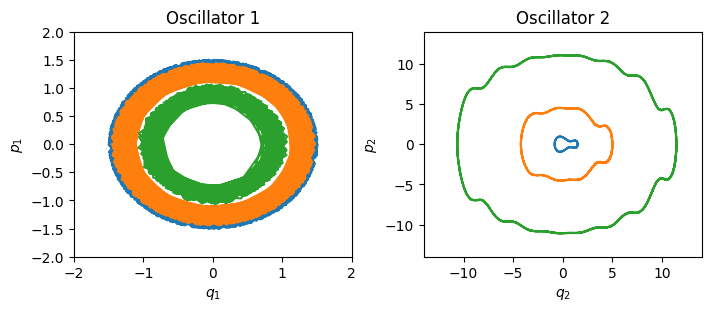

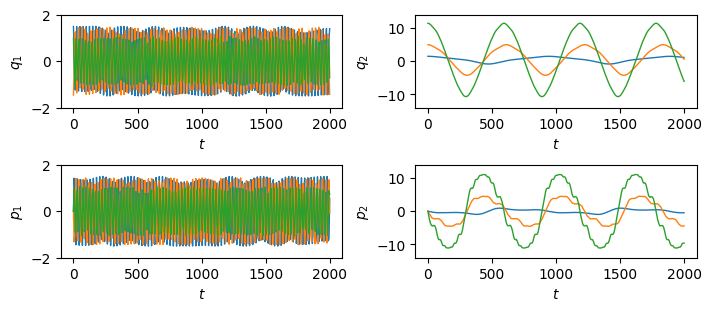

Model: T0Centered: data at 5
Dt: 5.0
	Prediction time: 4.63e+00s
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))


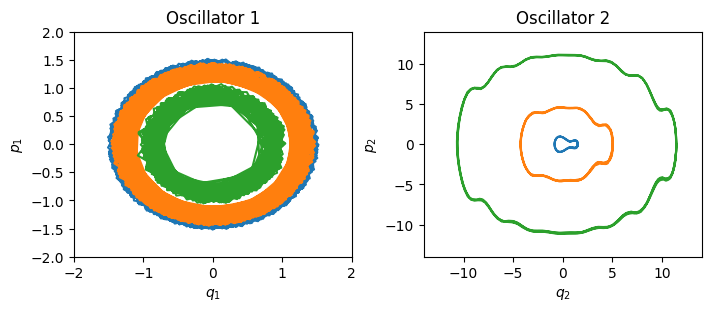

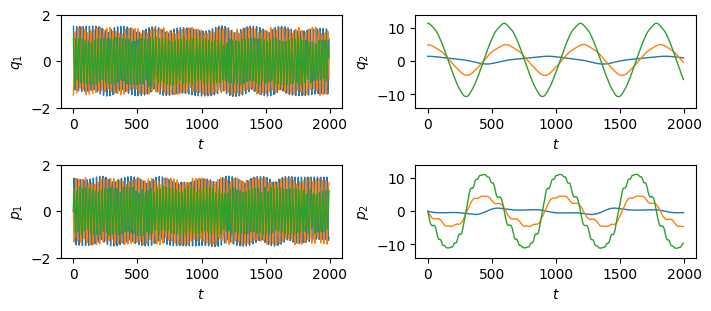

Model: T0Centered: data at 5 + VV normal(5,0.5) h=0.01
Dt: 5.0
	Prediction time: 4.82e+00s
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))


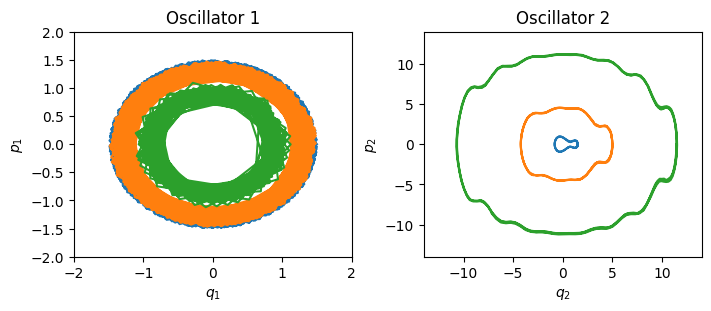

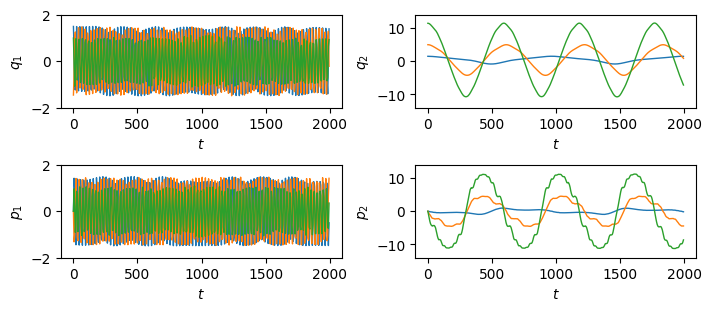

Model: T0Centered: data at 5 + IM normal(5,0.5) h=0.01
Dt: 5.0
	Prediction time: 4.73e+00s
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 1.5], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[ 0.       0.      -1.45433  5.     ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[ 0.       0.       1.      11.45256], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))


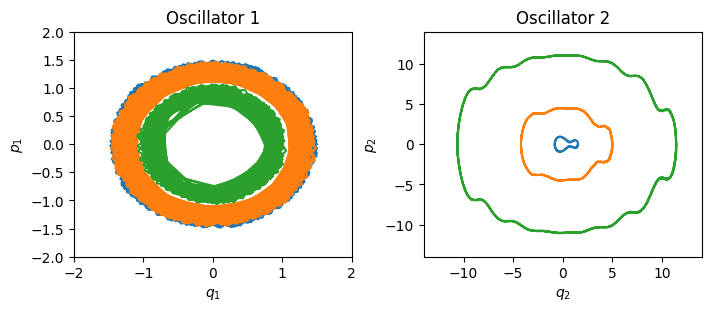

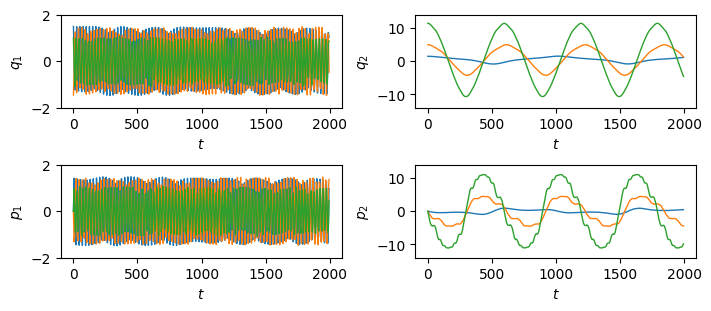

In [7]:
# Configuration
epsilon = 0.01
params = {"epsilon": epsilon}
processor = NCO(epsilon=epsilon)

# Select reference trajectory indices to use as initial conditions
ref_traj_indices = [1, 2, 3]

# Load reference trajectories
ref_filepaths = NCO.get_reference_filepaths('constant_energy')
ref_trajs = [Trajectory.load_from_file(
    ref_filepaths[epsilon][idx]["filepath"], 
    dt=ref_filepaths[epsilon][idx]["dt"],
    **params
) for idx in ref_traj_indices]

# Extract initial conditions
u0_list = [ref_traj.states.u[0] for ref_traj in ref_trajs]

# Simulation parameters
T_end = 2000
dt_list = [5.0]

# Phase space axis limits for plotting
phase_space_axis_lims = [[(-2, 2), (-2, 2)], [(-14, 14), (-14, 14)]]
q1_lim, p1_lim = phase_space_axis_lims[0]
q2_lim, p2_lim = phase_space_axis_lims[1]

print("Reference Trajectories:")
trajs = [ref_traj.select_between(0, T_end).select_with_interval(min(dt_list)) for ref_traj in ref_trajs]
for traj in trajs:
    print(traj)
    
# Plot reference trajectories
viz.plot_phase_space(
    trajs, 
    axis_lims=phase_space_axis_lims,
    figsize=(7, 3),
    show_legend=False
)

# viz.plot_phase_space_matlab(
#     trajs, 
#     axis_lims=phase_space_axis_lims,
#     show_legend=False,
#     figsize=(5,2),
#     # save_path=f"./out/nco/eps=1e-2/various_T/various_T_phase_space_ref.pdf"
# )

viz.plot_pq_vs_t(
    trajs, 
    ylims=[q1_lim, q2_lim, p1_lim, p2_lim], 
    figsize=(7, 3),
    show_legend=False,
)

# Generate predictions for each model and initial condition
for model, label in zip(models, model_labels):
    for dt in dt_list:
        print(f"Model: {label}\nDt: {dt}")
    
        pred_trajs = []
        start = time.time()
        u_seq_list = recursive_predict(model, u0_list, dt, params, int(T_end//dt))
        print(f"\tPrediction time: {time.time()-start:.2e}s")
        
        for u_seq in u_seq_list:
            traj = Trajectory.from_vx(np.arange(len(u_seq))*dt, u_seq, **params)
            print(traj)
            pred_trajs.append(traj)

        # Plot predicted trajectories
        viz.plot_phase_space(
            pred_trajs, 
            axis_lims=phase_space_axis_lims,
            figsize=(7, 3),
            show_legend=False,
        )

        # viz.plot_phase_space_matlab(
        #     pred_trajs, 
        #     axis_lims=phase_space_axis_lims,
        #     show_legend=False,
        #     figsize=(5,2),
        #     # save_path=f"./out/nco/eps=1e-2/various_T/various_T_phase_space_{label}.pdf"
        # )

        viz.plot_pq_vs_t(
            pred_trajs, 
            ylims=[q1_lim, q2_lim, p1_lim, p2_lim],
            figsize=(7, 3),
            show_legend=False,
        )


#### b. Fixed $q_1$ Trajectories

Reference Trajectories:
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 0. ], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.   0.   1.5  0.15], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 0.3], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 0.4], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 1. ], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.   0.   1.5  1.45], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.   0.   1.5  1.55], states=States(problem=NCO(epsilon=0.01), shape=(401, 4)))
NCOTrajectory(t_range=[0.0, 2000.0], dt=5.0, u0=[0.  0.  1.5 4. ], states=States(problem=

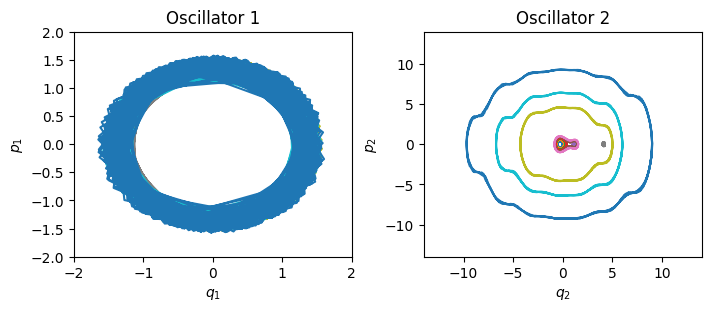

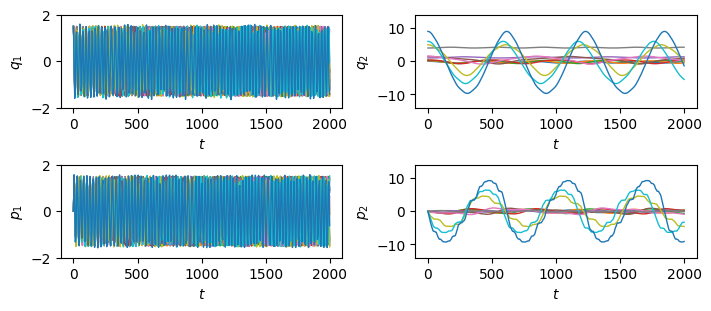

Model: T0Centered: data at 5
Dt: 5.0
	Prediction time: 4.31e+00s
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0. ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  0.15], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0.3], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0.4], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 1. ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  1.45], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  1.55], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=

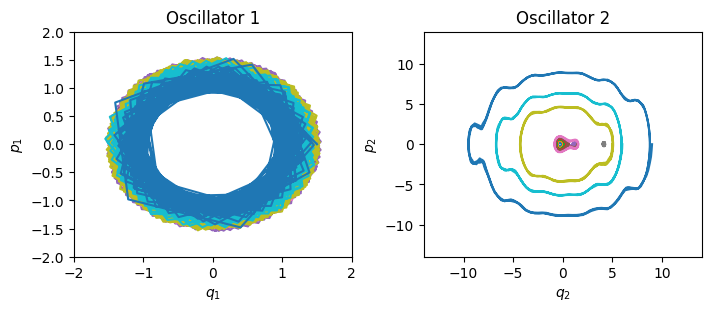

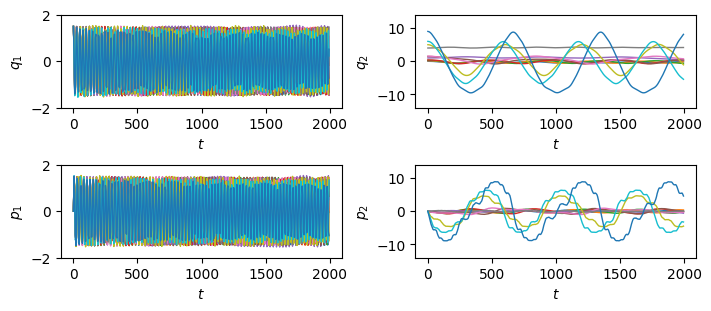

Model: T0Centered: data at 5 + VV normal(5,0.5) h=0.01
Dt: 5.0
	Prediction time: 4.34e+00s
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0. ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  0.15], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0.3], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0.4], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 1. ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  1.45], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  1.55], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=

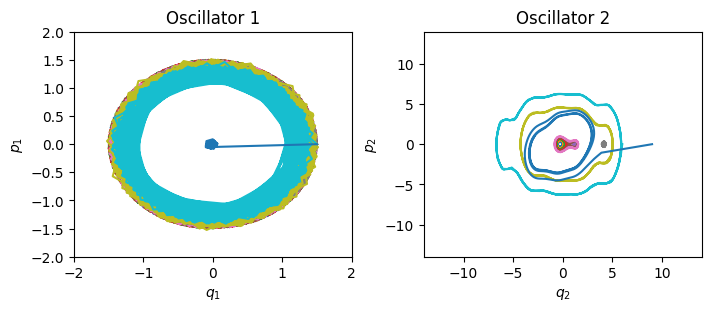

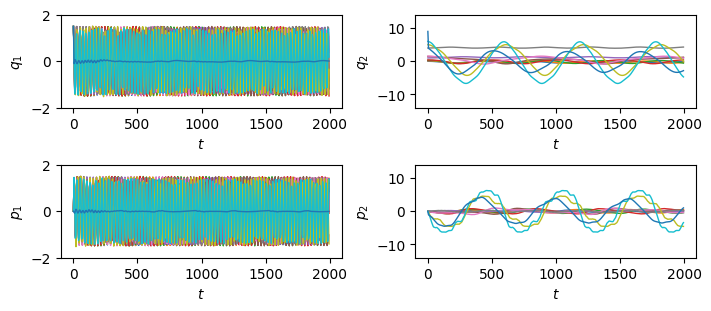

Model: T0Centered: data at 5 + IM normal(5,0.5) h=0.01
Dt: 5.0
	Prediction time: 4.76e+00s
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0. ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  0.15], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0.3], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 0.4], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.  0.  1.5 1. ], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  1.45], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=[0.0, 1995.0], dt=5.0, u0=[0.   0.   1.5  1.55], states=States(problem=NCO(epsilon=0.01), shape=(400, 4)))
NCOTrajectory(t_range=

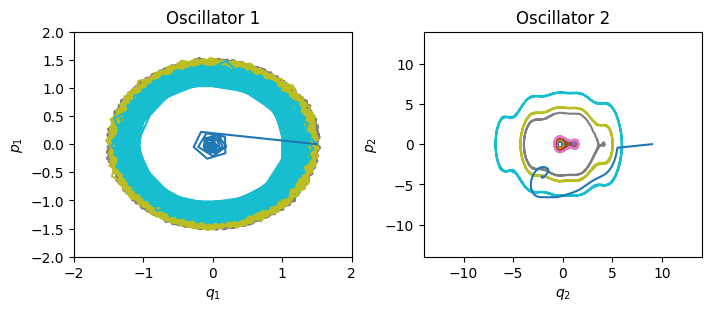

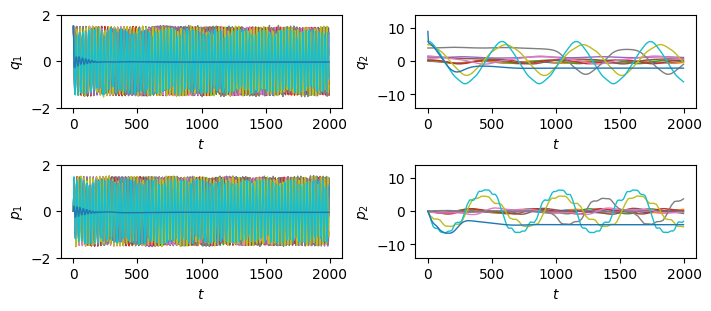

In [8]:
# Configuration
epsilon = 0.01
params = {"epsilon": epsilon}
processor = NCO(epsilon=epsilon)

# Select reference trajectory indices to use as initial conditions
ref_traj_indices = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

# Load reference trajectories
ref_filepaths = NCO.get_reference_filepaths('fixed_q1')
ref_trajs = [Trajectory.load_from_file(
    ref_filepaths[epsilon][idx]["filepath"], 
    dt=ref_filepaths[epsilon][idx]["dt"],
    **params
) for idx in ref_traj_indices]

# Extract initial conditions
u0_list = [ref_traj.states.u[0] for ref_traj in ref_trajs]

# Simulation parameters
T_end = 2000
dt_list = [5.0]

# Phase space axis limits for plotting
# phase_space_axis_lims = [[(-2, 2), (-2, 2)], [(-1, 1.6), (-1.4, 1.4)]]
phase_space_axis_lims = [[(-2, 2), (-2, 2)], [(-14, 14), (-14, 14)]]
q1_lim, p1_lim = phase_space_axis_lims[0]
q2_lim, p2_lim = phase_space_axis_lims[1]

print("Reference Trajectories:")
trajs = [ref_traj.select_between(0, T_end).select_with_interval(min(dt_list)) for ref_traj in ref_trajs]
for traj in trajs:
    print(traj)
    
# Plot reference trajectories
viz.plot_phase_space(
    trajs, 
    axis_lims=phase_space_axis_lims,
    figsize=(7, 3),
    show_legend=False,
)

# viz.plot_phase_space_matlab(
#     trajs, 
#     axis_lims=phase_space_axis_lims,
#     show_legend=False,
#     figsize=(5,2),
#     # save_path=f"./out/nco/eps=1e-2/best/phase_space_fixedq1_ref.pdf"
# )

viz.plot_pq_vs_t(
    trajs, 
    ylims=[q1_lim, q2_lim, p1_lim, p2_lim], 
    figsize=(7, 3),
    show_legend=False,
)

# Generate predictions for each model and initial condition
for model, label in zip(models, model_labels):
    for dt in dt_list:
        print(f"Model: {label}\nDt: {dt}")
    
        pred_trajs = []
        start = time.time()
        u_seq_list = recursive_predict(model, u0_list, dt, params, int(T_end//dt))
        print(f"\tPrediction time: {time.time()-start:.2e}s")
        
        for u_seq in u_seq_list:
            traj = Trajectory.from_vx(np.arange(len(u_seq))*dt, u_seq, **params)
            print(traj)
            pred_trajs.append(traj)

        # Plot predicted trajectories
        viz.plot_phase_space(
            pred_trajs, 
            axis_lims=phase_space_axis_lims,
            figsize=(7, 3),
            show_legend=False,
        )

        # viz.plot_phase_space_matlab(
        #     pred_trajs, 
        #     axis_lims=phase_space_axis_lims,
        #     show_legend=False,
        #     figsize=(5,2),
        #     save_path=f"./out/nco/eps=1e-2/best/phase_space_fixedq1_{label}.pdf"
        # )

        viz.plot_pq_vs_t(
            pred_trajs, 
            ylims=[q1_lim, q2_lim, p1_lim, p2_lim],
            figsize=(7, 3),
            show_legend=False,
        )
